# Market Risk Project: VaR/ES Modeling and Backtesting of a 30-Stock Equity Portfolio

**Objective.** Build three \$500,000 portfolios from 30 U.S. stocks across 5 sectors, measure their 1-day market risk with three VaR/ES methods, and test whether the VaR forecasts were accurate.

**Timeline (5 years of data, Oct 2021 – Sep 2026)**
- Year 1: used only to estimate the first portfolio weights
- Year 2: portfolios are running; their returns fill the first 250-day VaR window
- Years 3–5: daily VaR forecasts are compared with actual returns (backtesting)

**Outline**
1. Setup & data
2. Portfolio construction
3. Performance
4. Market exposure: CAPM beta and sector weights
5. VaR & ES forecasts
6. Backtesting
7. Findings

## 1. Setup & data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize
from scipy.stats import norm, binom, chi2

INITIAL_CAPITAL = 500_000
START_DATE = "2021-10-01"   # 5 years of data
END_DATE = "2026-09-30"     # fixed end date so results are reproducible
LOOKBACK = 250              # trading days (~1 year) used for weights and VaR
VAR_LEVEL = 0.99
ES_LEVEL = 0.975
MAX_WEIGHT = 0.10           # max 10% in any one stock
EWMA_LAMBDA = 0.94          # RiskMetrics decay factor
RF_ANNUAL = 0.035           # constant risk-free rate (rough average 3-month T-bill yield over the period)

plt.rcParams["figure.figsize"] = (11, 5)

In [2]:
SECTORS = {
    "Technology":       ["AAPL", "MSFT", "NVDA", "ORCL", "CSCO", "IBM"],
    "Financials":       ["JPM", "BAC", "WFC", "GS", "MS", "C"],
    "Healthcare":       ["JNJ", "PFE", "MRK", "UNH", "LLY", "AMGN"],
    "Energy":           ["XOM", "CVX", "COP", "SLB", "EOG", "OXY"],
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],
}
TICKERS = [t for stocks in SECTORS.values() for t in stocks]
SECTOR_OF = pd.Series({t: s for s, stocks in SECTORS.items() for t in stocks})
BENCHMARK = "SPY"   # S&P 500 ETF, used as the market

In [3]:
raw = yf.download(TICKERS + [BENCHMARK], start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)
close = raw["Close"][TICKERS + [BENCHMARK]]
print("Tickers with missing data:", list(close.columns[close.isna().any()]))

prices = close.dropna()
returns = prices.pct_change().dropna()      # daily simple returns
stock_returns = returns[TICKERS]
spy_returns = returns[BENCHMARK]
print(f"{prices.index[0].date()} to {prices.index[-1].date()}, {len(prices)} trading days")

Tickers with missing data: []
2021-10-01 to 2026-09-28, 1252 trading days


## 2. Portfolio construction

On the first trading day of each quarter, each strategy chooses weights using **only the past 250 days** (no look-ahead bias). Weights are then held constant until the next rebalance. All portfolios are long-only, fully invested, with at most 10% per stock.

| Strategy | Idea | Estimated inputs |
|---|---|---|
| Equal Weight | 1/30 in each stock | None |
| Minimum Variance | Lowest portfolio volatility | Covariance matrix |
| Max Sharpe | Highest (return − risk-free) / volatility | Covariance matrix and expected returns |

In [4]:
def solve_weights(objective, n):
    """Minimize the objective subject to: weights sum to 1, and 0 <= weight <= MAX_WEIGHT."""
    result = minimize(objective, x0=np.ones(n) / n,
                      bounds=[(0, MAX_WEIGHT)] * n,
                      constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                      method="SLSQP", options={"ftol": 1e-10})
    return result.x

def get_weights(strategy, window):
    n = window.shape[1]
    if strategy == "Equal Weight":
        return np.ones(n) / n
    mu = window.mean().values * 252        # annualized mean returns
    cov = window.cov().values * 252        # annualized covariance matrix
    if strategy == "Min Variance":
        return solve_weights(lambda w: np.sqrt(w @ cov @ w), n)
    if strategy == "Max Sharpe":
        return solve_weights(lambda w: -(w @ mu - RF_ANNUAL) / np.sqrt(w @ cov @ w), n)

In [5]:
STRATEGIES = ["Equal Weight", "Min Variance", "Max Sharpe"]

eligible = stock_returns.index[LOOKBACK - 1:]                      # days with 250 past returns
rebalance_dates = eligible[~eligible.to_period("Q").duplicated()]  # first day of each quarter

weights, port_returns = {}, {}
for s in STRATEGIES:
    w = pd.DataFrame(index=stock_returns.index, columns=TICKERS, dtype=float)
    for d in rebalance_dates:
        window = stock_returns.loc[:d].iloc[-LOOKBACK:]            # past 250 days only
        w.loc[d] = get_weights(s, window)
    w = w.ffill()                                                  # hold weights until next rebalance
    weights[s] = w
    # yesterday's weights x today's stock returns = today's portfolio return
    port_returns[s] = (w.shift(1) * stock_returns).sum(axis=1, min_count=1)

port_returns = pd.DataFrame(port_returns).dropna()
port_returns["SPY (benchmark)"] = spy_returns
port_values = INITIAL_CAPITAL * (1 + port_returns).cumprod()
print(f"Portfolios run from {port_returns.index[0].date()}, {len(rebalance_dates)} rebalances")

Portfolios run from 2022-09-30, 17 rebalances


## 3. Performance

,Final Value ($),Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Equal Weight,1152362.0,0.234,0.132,1.392,-0.166
Min Variance,925764.0,0.168,0.111,1.137,-0.107
Max Sharpe,1201883.0,0.247,0.141,1.392,-0.160
SPY (benchmark),1111342.0,0.223,0.158,1.132,-0.188


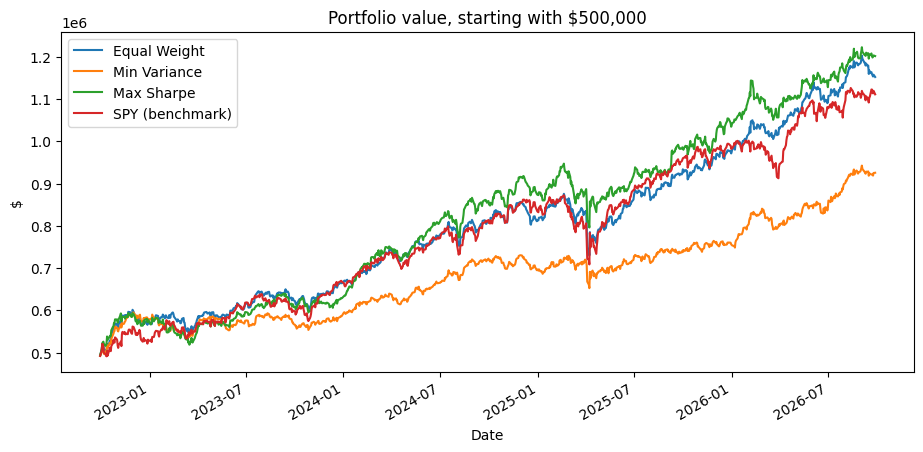

In [6]:
def performance_table(r):
    value = INITIAL_CAPITAL * (1 + r).cumprod()
    ann_vol = r.std() * np.sqrt(252)
    return pd.DataFrame({
        "Final Value ($)": value.iloc[-1].round(0),
        "Ann. Return": (1 + r).prod() ** (252 / len(r)) - 1,
        "Ann. Volatility": ann_vol,
        "Sharpe Ratio": (r.mean() * 252 - RF_ANNUAL) / ann_vol,
        "Max Drawdown": (value / value.cummax() - 1).min(),
    })

display(performance_table(port_returns).round(3))

port_values.plot(title="Portfolio value, starting with $500,000")
plt.ylabel("$")
plt.show()

## 4. Market exposure: CAPM beta and sector weights

Beta measures how much a stock moves with the market: $\beta_i = \mathrm{Cov}(r_i, r_m) / \mathrm{Var}(r_m)$, estimated over the last 250 days. (With a constant risk-free rate, using excess returns gives the same beta.) A portfolio's beta is the weighted average of its stocks' betas.

In [7]:
recent = returns.iloc[-LOOKBACK:]
betas = recent[TICKERS].apply(lambda r: r.cov(recent[BENCHMARK]) / recent[BENCHMARK].var())

latest_w = pd.DataFrame({s: weights[s].iloc[-1] for s in STRATEGIES})
display(pd.Series({s: latest_w[s] @ betas for s in STRATEGIES}, name="Portfolio beta").round(2))
display((latest_w.groupby(SECTOR_OF).sum() * 100).round(1).rename_axis("Sector weight (%)"))
display(pd.DataFrame({"Sector": SECTOR_OF, "Beta": betas}).sort_values("Beta", ascending=False).round(2))

,Portfolio beta
Equal Weight,0.43
Min Variance,0.25
Max Sharpe,0.41


,Equal Weight,Min Variance,Max Sharpe
Sector weight (%),,,
Consumer Staples,20.0,35.5,14.3
Energy,20.0,16.6,15.5
Financials,20.0,10.3,16.4
Healthcare,20.0,15.5,30.0
Technology,20.0,22.2,23.7


,Sector,Beta
ORCL,Technology,2.03
NVDA,Technology,1.88
GS,Financials,1.60
MS,Financials,1.39
C,Financials,1.35
CSCO,Technology,1.04
MSFT,Technology,0.96
IBM,Technology,0.89
JPM,Financials,0.79
WFC,Financials,0.75


## 5. VaR & ES forecasts

Each day, three methods forecast the next day's **99% VaR** and **97.5% ES** from the portfolio's last 250 daily returns. Forecasts are shifted by one day so that the forecast for day *t* only uses information up to day *t − 1*.

| Method | Idea |
|---|---|
| Historical Simulation (HS) | VaR = the 1st percentile of the last 250 returns; ES = average of the worst 2.5% |
| Parametric Normal | Assume returns are normal (mean 0) with the standard deviation of the last 250 days: VaR $= 2.33\,\sigma$ |
| EWMA (RiskMetrics) | Same as Normal, but recent days get more weight: $\sigma_t^2 = \lambda\sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2$, with $\lambda = 0.94$ |

Normal ES $= \sigma\,\varphi(z_{97.5\%}) / (1 - 0.975)$. Basel replaced 99% VaR with 97.5% ES because the two are almost equal under normality, but ES also reflects how large the losses beyond the cutoff are.

In [8]:
z = norm.ppf(VAR_LEVEL)
es_mult = norm.pdf(norm.ppf(ES_LEVEL)) / (1 - ES_LEVEL)

def hs_es(x):
    cutoff = np.quantile(x, 1 - ES_LEVEL)
    return -x[x <= cutoff].mean()

def var_es_forecasts(r):
    """VaR and ES as positive fractions of portfolio value (0.02 = 2% loss)."""
    roll = r.rolling(LOOKBACK)
    sigma = roll.std()
    sigma_ewma = np.sqrt((r ** 2).ewm(alpha=1 - EWMA_LAMBDA, adjust=False).mean())
    f = pd.DataFrame({
        "HS VaR": -roll.quantile(1 - VAR_LEVEL),
        "HS ES": roll.apply(hs_es, raw=True),
        "Normal VaR": z * sigma,
        "Normal ES": es_mult * sigma,
        "EWMA VaR": z * sigma_ewma,
        "EWMA ES": es_mult * sigma_ewma,
    }).shift(1)                          # forecast for day t uses data up to day t-1
    f["Actual Return"] = r
    return f.dropna()

forecasts = {s: var_es_forecasts(port_returns[s]) for s in STRATEGIES}
print(f"Backtest period: {forecasts['Equal Weight'].index[0].date()} to "
      f"{forecasts['Equal Weight'].index[-1].date()} ({len(forecasts['Equal Weight'])} days)")

# Latest forecasts in dollars = % forecast x portfolio value at the start of the day
cols = ["HS VaR", "Normal VaR", "EWMA VaR", "HS ES", "Normal ES", "EWMA ES"]
latest = pd.DataFrame({s: forecasts[s][cols].iloc[-1] * port_values[s].shift(1).iloc[-1] for s in STRATEGIES})
display(latest.round(0).rename_axis("Latest 1-day forecast ($)"))

Backtest period: 2023-09-29 to 2026-09-28 (751 days)


,Equal Weight,Min Variance,Max Sharpe
Latest 1-day forecast ($),,,
HS VaR,16851.0,12941.0,20292.0
Normal VaR,17337.0,12896.0,21357.0
EWMA VaR,16097.0,11398.0,16363.0
HS ES,17328.0,12771.0,20577.0
Normal ES,17423.0,12960.0,21463.0
EWMA ES,16177.0,11455.0,16443.0


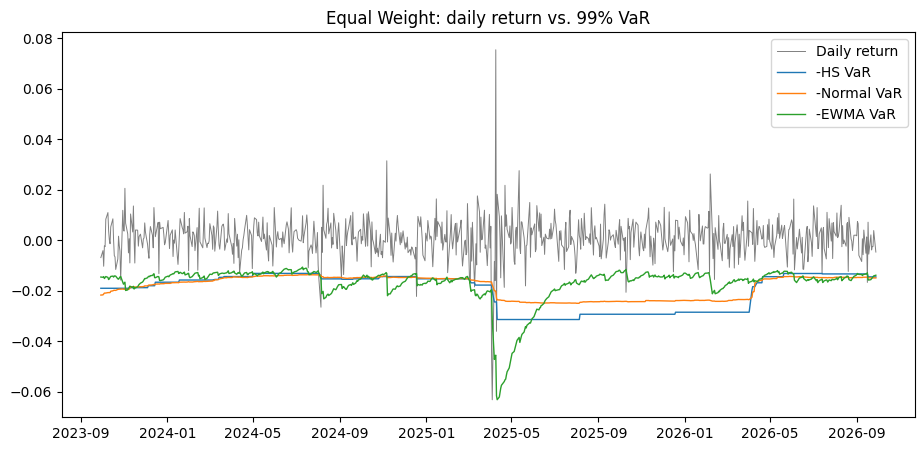

In [9]:
SHOW = "Equal Weight"    # change to "Min Variance" or "Max Sharpe"
f = forecasts[SHOW]

fig, ax = plt.subplots()
ax.plot(f.index, f["Actual Return"], color="grey", lw=0.7, label="Daily return")
for m in ["HS", "Normal", "EWMA"]:
    ax.plot(f.index, -f[f"{m} VaR"], lw=1, label=f"-{m} VaR")
ax.set_title(f"{SHOW}: daily return vs. 99% VaR")
ax.legend()
plt.show()

## 6. Backtesting

A **breach** is a day when the actual loss is bigger than the VaR forecast (return < −VaR). A correct 99% VaR should be breached on about 1% of days.

- **Kupiec test:** the number of breaches $x$ in $T$ days is Binomial$(T, p)$. It is a likelihood ratio test of $H_0: p = 1\%$ against $p = x/T$: $LR = -2[\ln L(0.01) - \ln L(x/T)] \sim \chi^2_1$. If the p-value < 5%, the model is rejected.
- **Basel traffic light:** breaches in the last 250 days. Green 0–4, Yellow 5–9, Red 10+.

In [10]:
def kupiec_test(breaches, p):
    T, x = len(breaches), int(breaches.sum())
    lr = -2 * (binom.logpmf(x, T, p) - binom.logpmf(x, T, x / T))
    return lr, chi2.sf(lr, df=1)            # sf = 1 - cdf, the p-value

p = 1 - VAR_LEVEL
rows = []
for s in STRATEGIES:
    f = forecasts[s]
    for m in ["HS", "Normal", "EWMA"]:
        breaches = f["Actual Return"] < -f[f"{m} VaR"]
        lr, p_value = kupiec_test(breaches, p)
        rows.append({"Portfolio": s, "Method": m,
                     "Days": len(breaches),
                     "Expected breaches": p * len(breaches),
                     "Actual breaches": int(breaches.sum()),
                     "Kupiec LR": lr,
                     "p-value": p_value,
                     "Result (5%)": "Reject" if p_value < 0.05 else "Not rejected"})

display(pd.DataFrame(rows).set_index(["Portfolio", "Method"]).round(3))

Days  Expected breaches  Actual breaches  Kupiec LR  \
Portfolio    Method                                                        
Equal Weight HS       751               7.51               12      2.295   
             Normal   751               7.51               11      1.433   
             EWMA     751               7.51               10      0.755   
Min Variance HS       751               7.51               11      1.433   
             Normal   751               7.51               10      0.755   
             EWMA     751               7.51                9      0.281   
Max Sharpe   HS       751               7.51                9      0.281   
             Normal   751               7.51                5      0.960   
             EWMA     751               7.51                8      0.032   

                     p-value   Result (5%)  
Portfolio    Method                         
Equal Weight HS        0.130  Not rejected  
             Normal    0.231  Not rejected  
             EWMA      0.385  Not rejected  
Min Variance HS        0.231  Not rejected  
             Normal    0.385  Not rejected  
             EWMA      0.596  Not rejected  
Max Sharpe   HS        0.596  Not rejected  
             Normal    0.327  Not rejected  
             EWMA      0.859  Not rejected

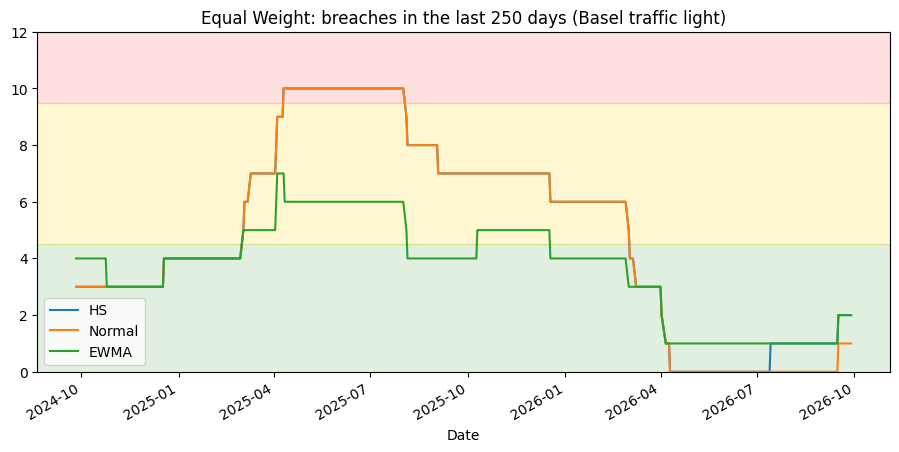

In [11]:
f = forecasts[SHOW]
counts = pd.DataFrame({m: (f["Actual Return"] < -f[f"{m} VaR"]).rolling(250).sum()
                       for m in ["HS", "Normal", "EWMA"]}).dropna()

fig, ax = plt.subplots()
top = max(12, counts.values.max() + 2)
ax.axhspan(0, 4.5, color="green", alpha=0.12)
ax.axhspan(4.5, 9.5, color="gold", alpha=0.18)
ax.axhspan(9.5, top, color="red", alpha=0.12)
counts.plot(ax=ax)
ax.set_ylim(0, top)
ax.set_title(f"{SHOW}: breaches in the last 250 days (Basel traffic light)")
plt.show()

## 7. Findings

**Performance**

1. All three portfolios grew from \$500,000 to between \$0.93M and \$1.20M between September 2022 and September 2026. However, the start date was close to the bottom of the 2022 bear market, so these high absolute returns mostly reflect a strong market period, not the strategies alone.
2. Max Sharpe did not beat Equal Weight on a risk-adjusted basis (Sharpe ratio 1.39 for both). It earned slightly more (24.7% vs. 23.4% per year) but with slightly higher volatility (14.1% vs. 13.2%). Optimizing on historical mean returns added no value out-of-sample, consistent with DeMiguel, Garlappi and Uppal (2009), who show that the simple 1/N portfolio is hard to beat because expected returns are estimated with large errors.
3. Minimum Variance achieved its goal: the lowest volatility (11.1%) and the smallest maximum drawdown (−10.7%). The cost was the lowest return (16.8% per year), since low-risk stocks lagged in a strong bull market.

**Market exposure**

4. Over the last 250 days, all five energy stocks had negative betas (−0.50 to −0.63), and consumer staples had betas near or below zero. This is not a data error: the window includes the oil supply shock that followed the U.S.–Israel strikes on Iran in late February 2026, when oil prices surged while the broader market fell. As a result, the Equal Weight portfolio's beta is only 0.43, because negative-beta energy stocks offset high-beta names such as Oracle (2.03), Nvidia (1.88) and Goldman Sachs (1.60). Beta is not a fixed property of a stock: one major event can even change its sign.

**VaR and backtesting**

5. On the last day, the Equal Weight portfolio's 1-day 99% VaR from historical simulation was about \$16,900, or roughly 1.5% of its value: on 99 out of 100 days, the daily loss should not exceed this amount. In the current calm market, the three methods give similar values (\$16,100–\$17,300).
6. EWMA reacts fastest to new information. After the April 2025 tariff shock, EWMA VaR jumped from about 1.5% to about 6% of portfolio value and returned to normal within about three months. Historical-simulation VaR rose only to about 3% but stayed there for a full year, then dropped suddenly in April 2026 when the shock days left the 250-day window (the "ghost effect"). EWMA adapts quickly but can underestimate risk after calm periods; historical simulation is stable but slow.
7. Over 751 backtesting days, a correct 99% VaR should be breached about 7.5 times. Actual breaches ranged from 5 to 12 across the nine portfolio–method combinations, and the Kupiec test did not reject any of them at the 5% level. EWMA's breach count was the closest to the expected number in all three portfolios (10, 9 and 8 breaches), making it the best-calibrated method in this sample.